# Restaurants - classification problem

### Imports and setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.base import clone

# Imblearn for SMOTE inside the pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

### Load Data

Training data shape: (33296, 86)
Test data shape: (8325, 85)

Target Variable Distribution (status_closed):
status_closed
0    30028
1     3268
Name: count, dtype: int64

Percentage:
status_closed
0    90.185007
1     9.814993
Name: proportion, dtype: float64


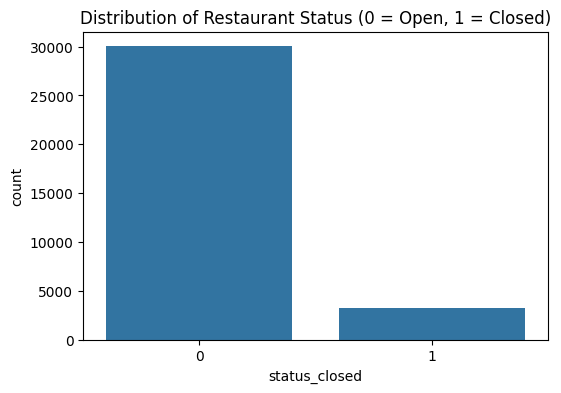

In [26]:

# Assuming the CSV files are in the same directory as this notebook
train_df = pd.read_csv('data/restaurants_train.csv')
test_df = pd.read_csv('data/restaurants_test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}\n")

# Check the target variable imbalance
target_counts = train_df['status_closed'].value_counts()
target_props = train_df['status_closed'].value_counts(normalize=True) * 100

print("Target Variable Distribution (status_closed):")
print(target_counts)
print(f"\nPercentage:\n{target_props}")

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='status_closed')
plt.title("Distribution of Restaurant Status (0 = Open, 1 = Closed)")
plt.show()

### Preprocessing

In [ ]:
#separate features and target from the RAW data
X_train_raw = train_df.drop(columns=['restaurant_id', 'status_closed'])
y_train_raw = train_df['status_closed']
X_test_kaggle = test_df.drop(columns=['restaurant_id'])

# identify Column Types
cat_cols = ['category_top20', 'price_level', 'has_photo', 'type_meal_takeaway', 
            'type_meal_delivery', 'type_bar', 'type_cafe', 'type_night_club', 
            'weekends_only', 'workdays_only', 'affiliated']

num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

# 3. Create the ColumnTransformer Blueprint
# For numeric: Impute with median, flag missings, and fix skewness
numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), 
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

# For categorical: Impute with mode, then One-Hot Encode
categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine into a single preprocessor step
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

### Train/Test split

In [28]:
# split the data randomly into train (80%) and validation (20%)
# we use stratify to maintain the 10:1 target distribution
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, 
    y_train_raw, 
    test_size=0.2, 
    stratify=y_train_raw, 
    random_state=123
)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Training set size: (26636, 84)
Validation set size: (6660, 84)


## Defining and Training the Models

### Logistic Regression / Elastic net

In [ ]:
# Cell 6: SMOTE + Elastic Net Master Pipeline

# 1. Build the Master Pipeline with a cloned preprocessor
master_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', SMOTE(random_state=123)),
    ('model', LogisticRegression(solver='saga', max_iter=10000, random_state=123))
])

# 2. Hyperparameter Grid
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 5, 10.0],
    'model__l1_ratio': [0, 0.1, 0.5, 0.9] 
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search = GridSearchCV(
    estimator=master_pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training Master Pipeline with Missing Indicators & PowerTransforms...")
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Balanced Accuracy: {grid_search.best_score_:.4f}")

Training Master Pipeline with Missing Indicators & PowerTransforms...
Best Parameters: {'model__C': 0.01, 'model__l1_ratio': 0.1}
Best CV Balanced Accuracy: 0.6775


### K-nearest neighbours (KNN)

In [ ]:
# Cell 7: SMOTE + K-Nearest Neighbours

# 1. Build the KNN Pipeline with a cloned preprocessor
knn_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', SMOTE(random_state=123)),
    ('model', KNeighborsClassifier())
])

# 2. Hyperparameter Grid for KNN
param_grid_knn = {
    'model__n_neighbors': [5, 15, 30, 50],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2] 
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Searching for optimal SMOTE + KNN...")
knn_search.fit(X_train, y_train)

print("Best Parameters:", knn_search.best_params_)
print(f"Best CV Balanced Accuracy: {knn_search.best_score_:.4f}")

Searching for optimal SMOTE + KNN...
Best Parameters: {'model__n_neighbors': 50, 'model__p': 1, 'model__weights': 'uniform'}
Best CV Balanced Accuracy: 0.6366


### Support Vector Machine (SVM)

In [ ]:
# Cell 8: RandomUnderSampler + Support Vector Machine (RBF Kernel)

# 1. Build the SVM Pipeline with a cloned preprocessor
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
#    ('undersampler', RandomUnderSampler(random_state=123)),
    ('model', SVC(random_state=123, probability=True, class_weight='balanced')) 
])

# 2. Hyperparameter Grid for SVM
param_grid_svm = {
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': ['scale', 'auto'],
    'model__kernel': ['rbf'] 
}

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Searching for optimal SVM... (This may take a while!)")
svm_search.fit(X_train, y_train)

print("Best Parameters:", svm_search.best_params_)
print(f"Best CV Balanced Accuracy: {svm_search.best_score_:.4f}")

Searching for optimal SMOTE + SVM... (This may take a while!)
Best Parameters: {'model__C': 0.1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV Balanced Accuracy: 0.6484


In [ ]:
# Cell 8: RandomUnderSampler + Support Vector Machine (RBF Kernel)
from imblearn.under_sampling import RandomUnderSampler

# 1. Build the SVM Pipeline
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('undersampler', RandomUnderSampler(random_state=123)), # Prevents the 4-hour runtime!
    ('model', SVC(random_state=123, probability=True))
])

# 2. Hyperparameter Grid for SVM
param_grid_svm = {
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': ['scale', 'auto'],
    'model__kernel': ['rbf'] 
}

svm_search_u = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Searching for optimal Undersampled SVM...")
svm_search_u.fit(X_train, y_train)

print("Best Parameters:", svm_search_u.best_params_)
print(f"Best CV Balanced Accuracy: {svm_search_u.best_score_:.4f}")

Searching for optimal Undersampled SVM...
Best Parameters: {'model__C': 1.0, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV Balanced Accuracy: 0.6704


### Model Evaluaton

In [ ]:
# Cell 9: Automatic Best Model Selection, Threshold Tuning & Export

# 1. Automatically compare and select the best model from Cells 6, 7, and 8
searches = {
    'Elastic Net': grid_search,
    'KNN': knn_search,
    'SVM (RBF, balanced)': svm_search,
    'SVM (RBF, undersampled)': svm_search_u
}

best_overall_name = ""
best_overall_score = 0
best_model = None

for name, search_obj in searches.items():
    if search_obj.best_score_ > best_overall_score:
        best_overall_score = search_obj.best_score_
        best_model = search_obj.best_estimator_
        best_overall_name = name

print("-" * 30)
print(f"BEST MODEL: {best_overall_name}")
print(f"Best CV Balanced Accuracy: {best_overall_score:.4f}")
print("-" * 30)

# 2. LEAK-FREE THRESHOLD TUNING
# We use cross_val_predict on X_train to get unbiased, out-of-fold probabilities.
print("\nCalculating Out-Of-Fold probabilities for leak-free threshold tuning...")
oof_train_probs = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

thresholds = np.linspace(0.2, 0.8, 100)
best_threshold = 0.5
best_train_bacc = 0

for t in thresholds:
    custom_preds = (oof_train_probs >= t).astype(int)
    score = balanced_accuracy_score(y_train, custom_preds)
    if score > best_train_bacc:
        best_train_bacc = score
        best_threshold = t

print(f"Optimal Threshold (Found via CV on Train): {best_threshold:.3f}")

# 3. EVALUATE ON UNTOUCHED VALIDATION SET
val_probs = best_model.predict_proba(X_val)[:, 1]
final_val_preds = (val_probs >= best_threshold).astype(int)

print(f"\nDefault 0.5 Threshold Val Balanced Accuracy: {balanced_accuracy_score(y_val, best_model.predict(X_val)):.4f}")
print(f"OPTIMIZED Threshold ({best_threshold:.3f}) Val Balanced Accuracy: {balanced_accuracy_score(y_val, final_val_preds):.4f}")

# ---------------------------------------------------------
# FINAL KAGGLE SUBMISSION PREPARATION
# ---------------------------------------------------------
print(f"\nRetraining {best_overall_name} on the FULL training dataset...")
best_model.fit(X_train_raw, y_train_raw)

# Generate probabilities for the Kaggle test set
test_probs = best_model.predict_proba(X_test_kaggle)[:, 1]

# Apply our highly optimized threshold!
final_test_predictions = (test_probs >= best_threshold).astype(int)

# Create submission dataframe
submission = pd.DataFrame({
    'restaurant_id': test_df['restaurant_id'],
    'status_closed': final_test_predictions
})

# Save to CSV using the winner's name
submission_filename = f'submission_best_{best_overall_name.replace(" ", "_")}.csv'
submission.to_csv(submission_filename, index=False)
print(f"Submission saved to {submission_filename}!")

------------------------------
BEST MODEL: Elastic Net
Best CV Balanced Accuracy: 0.6775
------------------------------

Default 0.5 Threshold Val Balanced Accuracy: 0.6764
OPTIMIZED Threshold (0.503) Val Balanced Accuracy: 0.6762

Retraining Elastic Net on the FULL training dataset...
Submission saved to submission_best_Elastic_Net.csv!
